Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

Read data

In [3]:
merged_data = pd.read_csv("../../data/processed/merged_clean.csv")

Subset data for subgroup: 
Per_Level_Label = ["B2.1", "B2.2", "C1"],
Prof_Use_Label = "Yes"

In [4]:
subgroup = merged_data[
    (merged_data["Per_Level_Label"].isin(["B2.1", "B2.2", "C1"])
    ) & (merged_data["Prof_Use_Label"] == "Yes")      
]

In [5]:
subgroup.shape

(198, 31)

Actors data: Focus = "I"

In [6]:
subgroup_actors = subgroup[subgroup["Focus"] == "I"].copy()

In [7]:
subgroup_actors.shape

(120, 31)

Goal_Type

Chi-square test: if Goal_Type  had no relationship with actors' response, what frequencies would we expect by chance?

Observed frequencies

In [8]:
goal_response_a = pd.crosstab(
    subgroup_actors["Goal_Type"],
    subgroup_actors["Response_Full"]
)

goal_response_a

Response_Full,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,13,10,16
goal_non_frequent,18,9,13
no_goal,22,5,11


Chi-square: Goal_type alone does not strongly organise actors' responses (p-value: 0.2857)

In [9]:
chi2, p, dof, expected = chi2_contingency(goal_response_a)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 5.015402184707051
p-value: 0.2857207828157395
Degrees of freedom: 4


Cramér's V test: how strong does the association appear to be?

Cramér's V: 0.1464 = small. Goal_Type by itself is not carrying the system for actors.

In [10]:
n = goal_response_a.sum().sum()

k = min(goal_response_a.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.14640130692616188


Residuals

In [11]:
table = Table(goal_response_a)

In [12]:
residuals = table.standardized_resids

print(residuals)

Response_Full      L1_transfer  L2_other   correct
Goal_Type                                         
goal_frequent        -1.838561  0.971364  1.102535
goal_non_frequent    -0.046851  0.383666 -0.277440
no_goal               1.898225 -1.366433 -0.828835


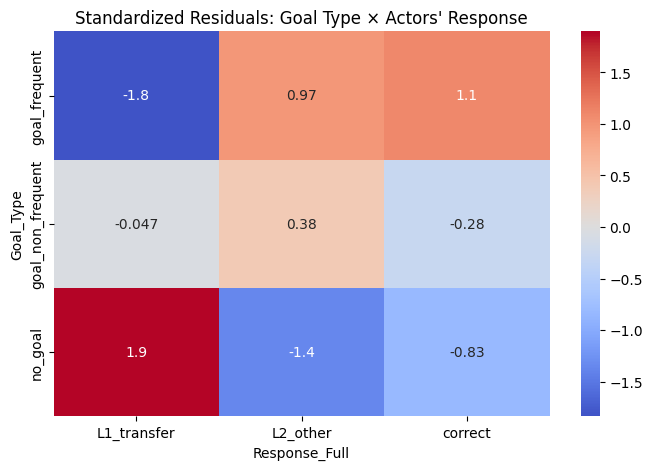

In [13]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Goal Type × Actors' Response")
plt.show()

Agent

Chi-square test: if Agent had no relationship with actors'response, what frequencies would we expect by chance?

Observed frequencies

In [14]:
agent_response_a = pd.crosstab(
    subgroup_actors["Agent"],
    subgroup_actors["Response_Full"]
)

agent_response_a

Response_Full,L1_transfer,L2_other,correct
Agent,,,
0,26,19,24
1,27,5,16


Chi-square: actors' response distributions differ by Agent more than what is expected by chance alone (p_value: 0.0446) 

In [15]:
chi2, p, dof, expected = chi2_contingency(agent_response_a)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 6.216574805168171
p-value: 0.044677404265568245
Degrees of freedom: 2


Cramér's V: 0.2305. The overall magnitude of the association is still moderate but higher for actors than for the whole group.

In [16]:
n = agent_response_a.sum().sum()

k = min(agent_response_a.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.2305062211587582


Residuals

In [17]:
table = Table(agent_response_a)

In [18]:
residuals = table.standardized_resids

print(residuals)

Response_Full  L1_transfer  L2_other  correct
Agent                                        
0                  -1.9847  2.255712  0.16256
1                   1.9847 -2.255712 -0.16256


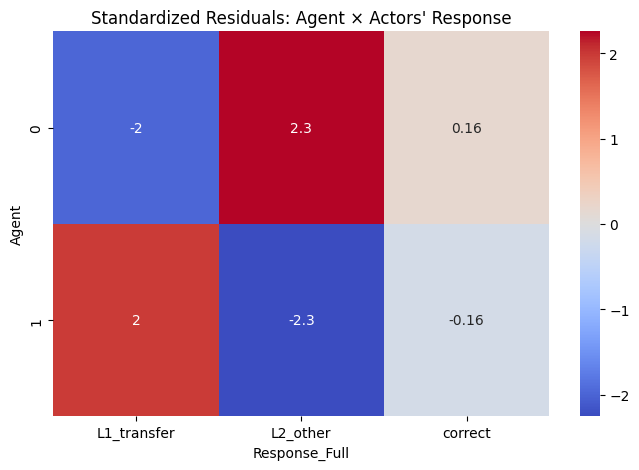

In [19]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Agent × Actors' Response")
plt.show()

Goal_Type X Agent

Chi-square test: if Goal_Type X Agent had no relationship with actors' responses, what frequencies would we expect by chance? 

Observed Frequencies

In [20]:
goal_agent_response_a = pd.crosstab(
    [subgroup_actors["Goal_Type"], subgroup_actors["Agent"]],
    subgroup_actors["Response_Full"]
)

goal_agent_response_a

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Agent                                
goal_frequent     0                6         8        9
                  1                7         2        7
goal_non_frequent 0                7         8        9
                  1               11         1        4
no_goal           0               13         3        6
                  1                9         2        5

Chi-square: highest chi-square value for the actors' subser but high p-value suggest that associations exist though they are distributed (p-value: 0.1226)

In [21]:
chi2, p, dof, expected = chi2_contingency(goal_agent_response_a)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 15.265412572712355
p-value: 0.12268084214134996
Degrees of freedom: 10


Expected Counts

In [22]:
expected_df = pd.DataFrame(
    expected,
    index= goal_agent_response_a.index,
    columns=goal_agent_response_a.columns
)

display(expected_df.round(2))

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Agent                                
goal_frequent     0            10.42      4.72     7.86
                  1             7.25      3.28     5.47
goal_non_frequent 0            10.87      4.92     8.21
                  1             7.25      3.28     5.47
no_goal           0             9.97      4.51     7.52
                  1             7.25      3.28     5.47

In [27]:
print(
    f"Cells with expected counts < 5: "
    f"{(expected_df < 5).sum().sum()}"
)

Cells with expected counts < 5: 6


In [28]:
goal_agent_response_a

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Agent                                
goal_frequent     0                6         8        9
                  1                7         2        7
goal_non_frequent 0                7         8        9
                  1               11         1        4
no_goal           0               13         3        6
                  1                9         2        5

Cramér's V: the association is stronger than any of the variable of its own but still moderate (Cramér's V: 0.2554).

In [23]:
n = goal_agent_response_a.sum().sum()

k = min(goal_agent_response_a.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.2554149679762173


Residuals

In [24]:
table = Table(goal_agent_response_a)

In [25]:
residuals = table.standardized_resids

print(residuals)

Response_Full            L1_transfer  L2_other   correct
Goal_Type         Agent                                 
goal_frequent     0        -2.065036  1.890816  0.557496
                  1        -0.133981 -0.854312  0.867861
goal_non_frequent 0        -1.780804  1.744622  0.383666
                  1         2.028191 -1.520675 -0.833922
no_goal           0         1.442182 -0.886433 -0.758865
                  1         0.947105 -0.854312 -0.266661


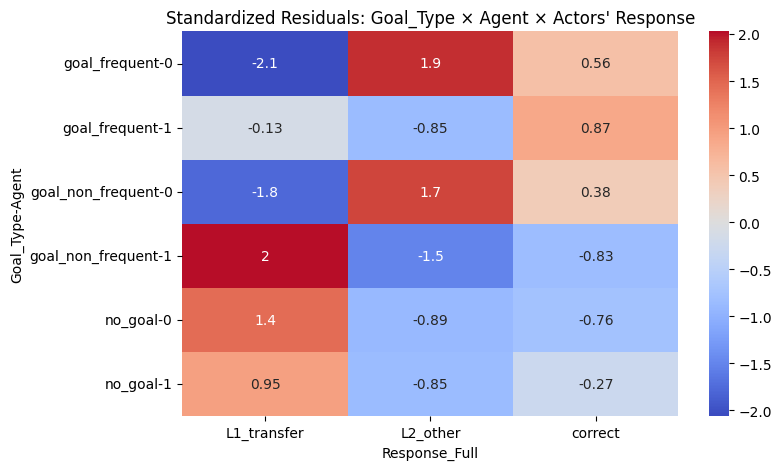

In [26]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals, 
    annot= True,
    cmap= "coolwarm",
    center = 0
)

plt.title("Standardized Residuals: Goal_Type × Agent × Actors' Response")
plt.show()